In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import pandas as pd
import os
import pingouin as pg
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from sqlalchemy import create_engine
from dotenv import load_dotenv

In [2]:
# Global style settings
plt.rcParams.update({
    'figure.figsize': (10, 8),   # Size of all plots
    'axes.grid': True,           # Enable grid
    'grid.alpha': 0.3,           # Grid transparency
    'grid.linestyle': '--',      # Grid style
    'font.size': 12,             # Base font size
    'axes.titlesize': 16,        # Title size
    'axes.labelsize': 14,        # Axis labels
})
plt.style.use('dark_background')

In [3]:
# Load credentials from .env
load_dotenv()
PG_URI = os.getenv("DATABASE_URL")

if not PG_URI:
    raise ValueError("DATABASE_URL not found. Check your .env file.")

# Initialize engine
engine = create_engine(PG_URI)

def get_donations():
    query = """
    SELECT
        d.id, d.date, d.foundation_name, d.category,
        ROUND((d.amount / NULLIF(er.rate_uah, 0))::numeric, 2) AS amount_eur,
        er.rate_uah AS eur_exchange_rate,
        d.currency AS original_currency,
        d.comment, d.source AS donation_source
    FROM donations d
    LEFT JOIN exchange_rates er ON d.date = er.date AND er.currency = 'EUR'
    ORDER BY d.date DESC;
    """
    return pd.read_sql(query, engine, parse_dates=['date'])

def get_news():
    query = """
    SELECT
        date,
        STRING_AGG(source, ' | ') AS daily_sources,
        STRING_AGG(headers, ' | ') AS daily_headers
    FROM news
    GROUP BY date
    ORDER BY date DESC;
    """
    return pd.read_sql(query, engine, parse_dates=['date'])

# Execution
df_donations = get_donations()
df_news = get_news()

# Global formatting settings
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_colwidth = 80

print(f"Extraction successful. Donations: {len(df_donations)} | News: {len(df_news)}")

Extraction successful. Donations: 2064044 | News: 440


In [4]:
df_donations.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source
0,9662778,2026-04-06,come_back_alive,general,87.55,50.31,UAH,UKR ***1983 (4405 UAH),Card payment
1,9662779,2026-04-06,come_back_alive,general,4.97,50.31,UAH,UKR ***7346 (250 UAH),Card payment
2,9662780,2026-04-06,come_back_alive,general,29.81,50.31,UAH,UKR ***7031 (1500 UAH),Card payment
3,9662781,2026-04-06,come_back_alive,general,4.97,50.31,UAH,ISR ***4367 (250 UAH),Card payment
4,9662782,2026-04-06,come_back_alive,general,14.91,50.31,UAH,UKR ***0517 (750 UAH),Card payment


In [5]:
df_news.head()

,date,daily_sources,daily_headers
0,2026-04-06,theguardian.com,['Ukraine war briefing: Russian oil facilities burn as Zelenskyy tours Middl...
1,2026-04-05,theguardian.com,['Ukraine war briefing: Slovakia PM calls on EU to lift sanctions on Russian...
2,2026-04-04,theguardian.com,['‘The frontline is like Terminator’: fighting robots give Ukraine hope in w...
3,2026-04-03,theguardian.com,['Ukraine war briefing: Zelenskyy offers expertise on keeping waterways open...
4,2026-04-02,theguardian.com,['Coordinated conflict: how the Ukraine and Iran wars are starting to overla...


In [6]:
df = df_donations.copy()

The goal is to study "grassroots" donations by filtering for transactions under €10,000.

Since we have transaction-level data only for the 'Come Back Alive' (CBA) foundation, while United24 provides only daily aggregates (which would be automatically filtered out by this limit), I am focusing exclusively on CBA. By looking only at payments under €10k, I want to analyze the behavior of "ordinary" people rather than large organizations or funds.

In [7]:
df = df.query('foundation_name == "come_back_alive" and amount_eur <= 10000')

In [8]:
df.dtypes

id                            int64
date                 datetime64[ns]
foundation_name              object
category                     object
amount_eur                  float64
eur_exchange_rate           float64
original_currency            object
comment                      object
donation_source              object
dtype: object

In [9]:
#aggregate donations into days
dayly = df.groupby('date', as_index = False)\
        .agg({'amount_eur':'sum'})
dayly.head()

,date,amount_eur
0,2025-01-01,"130,061.34"
1,2025-01-02,"119,679.23"
2,2025-01-03,"124,264.38"
3,2025-01-04,"51,120.76"
4,2025-01-05,"49,416.61"


<Axes: xlabel='date', ylabel='amount_eur'>

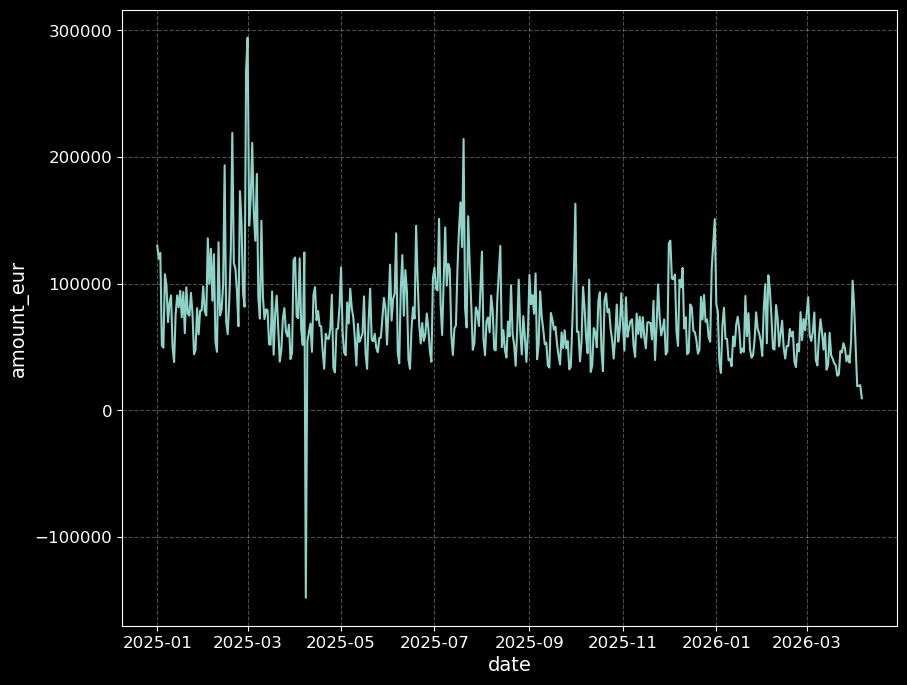

In [10]:
sns.lineplot(dayly, y = 'amount_eur', x = 'date')

Anomaly Detection: Negative Values
A quick look at the plot reveals a sharp drop into negative numbers. This is highly unusual behavior for donations. Let's dig deeper to investigate these negative records.

In [11]:
dayly[dayly.amount_eur < 0]

,date,amount_eur
97,2025-04-08,"-147,998.00"


<Axes: >

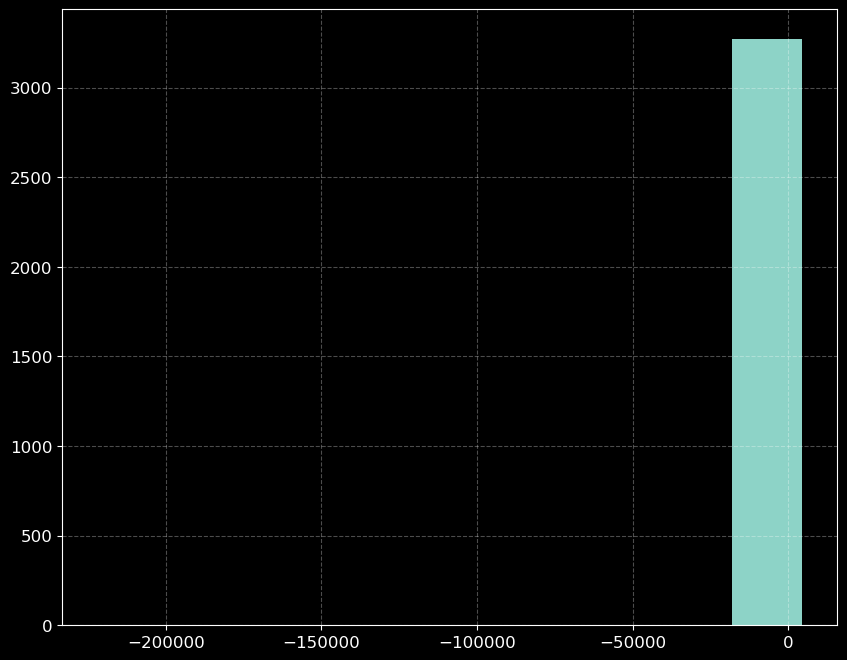

In [12]:
df[df.date == '2025-04-08'].amount_eur.hist()

In [13]:
df[(df['date'] == '2025-04-08') & (df['amount_eur'] < 0)]

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source
1520723,5346274,2025-04-08,come_back_alive,general,"-221,959.82",45.05,UAH,"Перерахування коштів згідно Додаткової Угоди № 2 від 27.03.2025 р., без ПДВ ...",Повернення коштів
1521514,5226638,2025-04-08,come_back_alive,general,-15.54,45.05,UAH,"Віталій Є. -- Благодійна пожертва на Фонд Повернись живим, STN15508792882736375",Monobank


Fortunately, there are only two records with negative donation amounts. This makes it easy to look into the raw data and find out exactly what caused the graph to anomalously drop below zero.

In [14]:
df.loc[1524092, 'comment']

'Юлія Д. -- Благодійна пожертва на РЕБнемо ворога!'

Translation
"Transfer of funds according to Addendum No. 2 dated March 27, 2025, VAT-exempt - PJSC UKRNAFTA"

Conclusion: This is a corporate accounting correction (likely a refund) from a major oil company. It is a technical transaction, not a regular grassroots donation, and must be removed from our dataset.

In [15]:
df = df[df['amount_eur'] >= 0]

<Axes: xlabel='date', ylabel='amount_eur'>

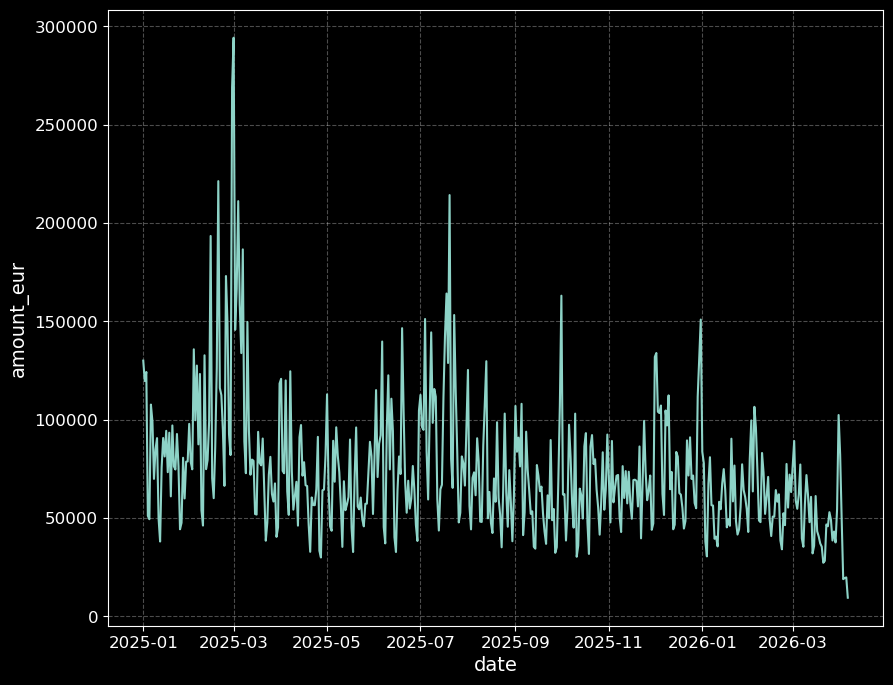

In [16]:
#lets's look at the gpaph now after I fixed it
dayly = df.groupby('date', as_index = False)\
        .agg({'amount_eur':'sum'})

sns.lineplot(dayly, y = 'amount_eur', x = 'date')

Okay, now everything is fine, we can start exploring public donations.

<Axes: xlabel='date', ylabel='amount_eur'>

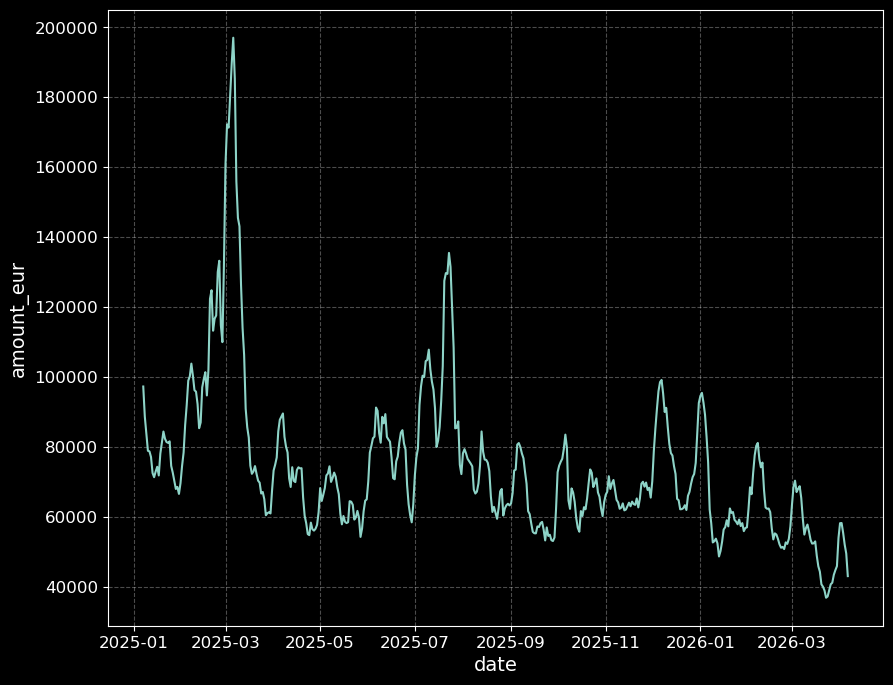

In [17]:
sns.lineplot(y = dayly.amount_eur.rolling(7).mean(), x = dayly.date)

Made the line smoother using rolling window 7 days. From the graph, it is clear that the trend is decreasing; let's verify this using linear regression.

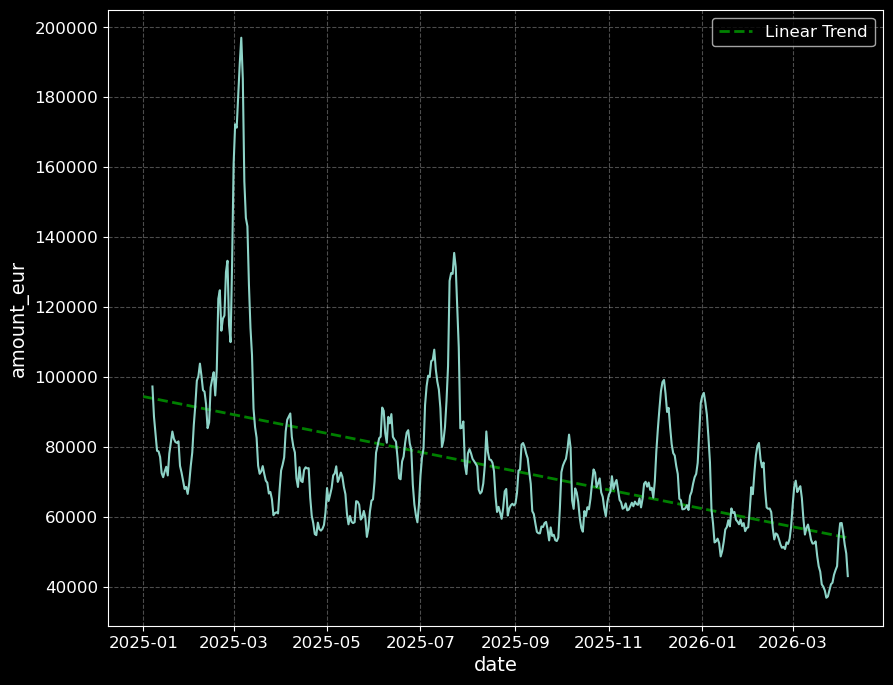

In [18]:
# 1. Convert datetime to numeric values for regression math
x_numeric = mdates.date2num(dayly['date'])
y_values = dayly['amount_eur']

# 2. Calculate linear regression 
coefficients = np.polyfit(x_numeric, y_values, 1)
trend_function = np.poly1d(coefficients)

plt.plot(dayly['date'], trend_function(x_numeric), color='green', linestyle='--', linewidth=2, label='Linear Trend')
sns.lineplot(y = dayly.amount_eur.rolling(7).mean(), x = dayly.date)
plt.legend()

In [19]:
dayly['weekday'] = dayly.date.dt.day_name()

In [20]:
dayly.head()

,date,amount_eur,weekday
0,2025-01-01,"130,061.34",Wednesday
1,2025-01-02,"119,683.82",Thursday
2,2025-01-03,"124,264.38",Friday
3,2025-01-04,"51,121.91",Saturday
4,2025-01-05,"49,418.91",Sunday


Let's see which days people donate most

<Axes: xlabel='weekday', ylabel='amount_eur'>

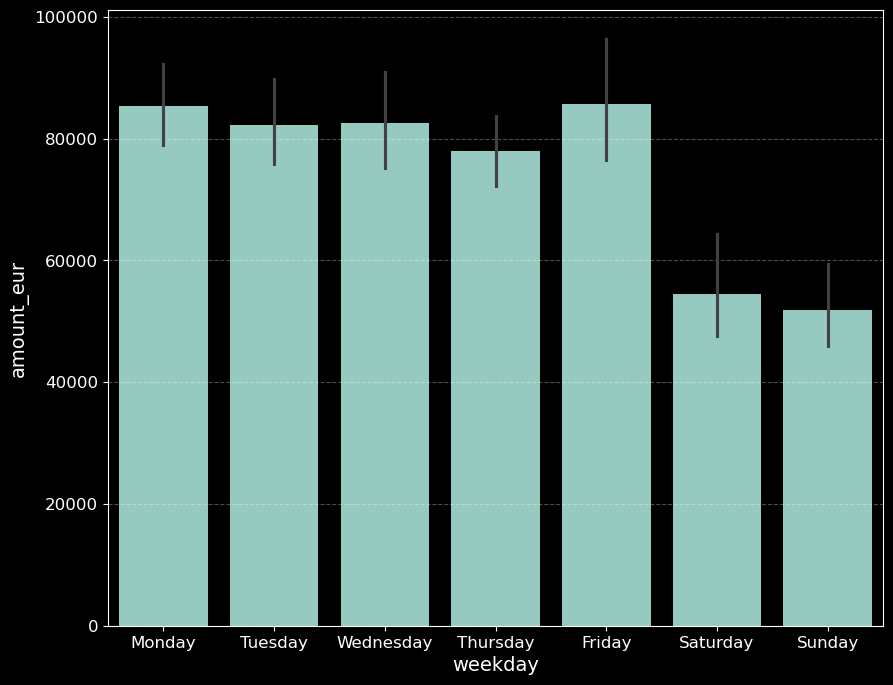

In [21]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(x = dayly.weekday, y = dayly.amount_eur, order = order)

<Axes: xlabel='weekday', ylabel='amount_eur'>

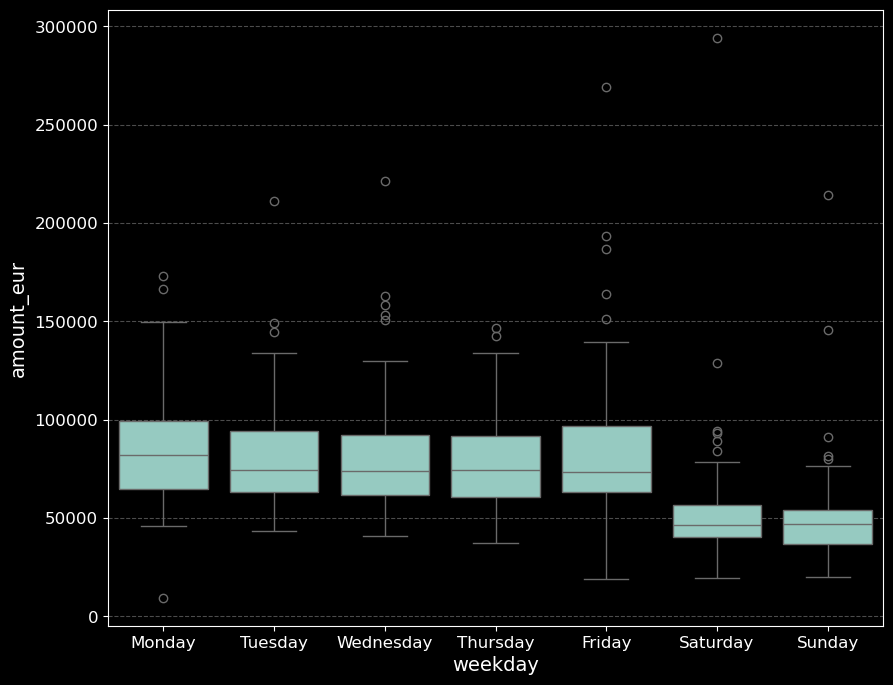

In [22]:
sns.boxplot(x = dayly.weekday, y = dayly.amount_eur, order = order)

We observe a fairly even and logical distribution across the days, with slightly lower values on weekends because many automated services do not operate then. The chart shows that Monday is one of the busiest days (as it includes automated transactions from the weekend). The boxplot also reveals a significant number of outliers, so let’s take a closer look at them.

In [23]:
dayly[dayly.amount_eur > 140000].shape

(21, 3)

In [24]:
dayly[(dayly.weekday.isin(['Saturday', 'Sunday'])) & (dayly.amount_eur > 70000)].shape

(17, 3)

In [25]:
#making two different datasets for working days and weekends for closer look
anomalies_work = dayly[dayly.amount_eur > 140000]
anomalies_week = dayly[(dayly.weekday.isin(['Saturday', 'Sunday'])) & (dayly.amount_eur > 70000)]

Fortunately for us (and unfortunately for the Ukrainian people), we do not have many days with such serious anomalies — only 38 — so we can take a closer look at them.

In [26]:
anomalies_week.head()

,date,amount_eur,weekday
17,2025-01-18,"93,407.18",Saturday
31,2025-02-01,"78,450.19",Saturday
32,2025-02-02,"74,794.37",Sunday
45,2025-02-15,"70,312.26",Saturday
52,2025-02-22,"94,483.60",Saturday


In [27]:
anomalies = pd.concat([anomalies_work, anomalies_week])\
            .sort_values('date').reset_index(drop = True)

In [28]:
anomalies.head(10)

,date,amount_eur,weekday
0,2025-01-18,"93,407.18",Saturday
1,2025-02-01,"78,450.19",Saturday
2,2025-02-02,"74,794.37",Sunday
3,2025-02-14,"193,431.93",Friday
4,2025-02-15,"70,312.26",Saturday
5,2025-02-19,"221,308.62",Wednesday
6,2025-02-22,"94,483.60",Saturday
7,2025-02-24,"173,063.82",Monday
8,2025-02-25,"149,013.04",Tuesday
9,2025-02-28,"269,009.70",Friday


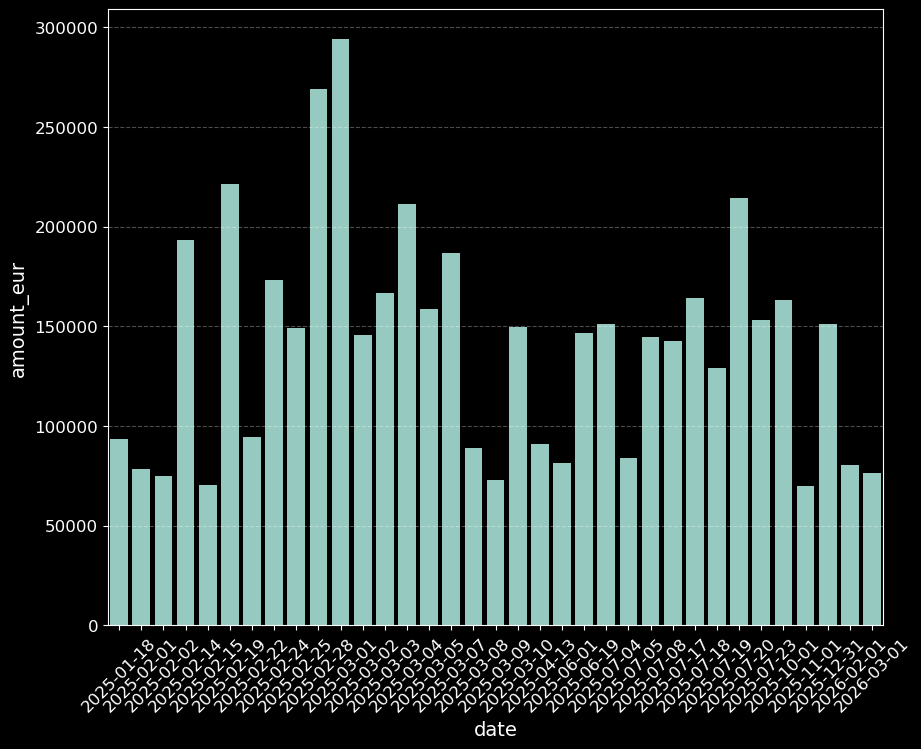

In [29]:
sns.barplot(x = anomalies.date, y = anomalies.amount_eur)
plt.xticks(rotation=45)
plt.show()

I found the highest density (and magnitude) of anomalies in the period from 2025-02-19 to 2025-02-28; let’s take a closer look at this period and try to understand what happened then.

In [30]:
start, end = '2025-02-19', '2025-02-28'

In [31]:
rush = dayly[(dayly.date >= start) & (dayly.date <= end)] 
rush

,date,amount_eur,weekday
49,2025-02-19,"221,308.62",Wednesday
50,2025-02-20,"116,136.31",Thursday
51,2025-02-21,"112,471.94",Friday
52,2025-02-22,"94,483.60",Saturday
53,2025-02-23,"66,376.59",Sunday
54,2025-02-24,"173,063.82",Monday
55,2025-02-25,"149,013.04",Tuesday
56,2025-02-26,"92,617.41",Wednesday
57,2025-02-27,"82,036.78",Thursday
58,2025-02-28,"269,009.70",Friday


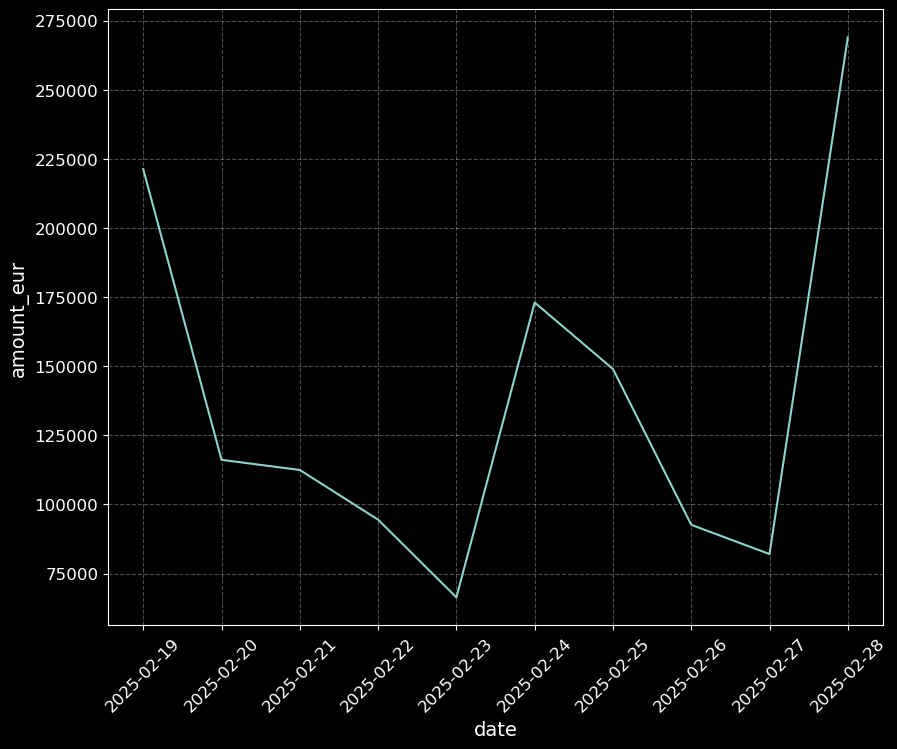

In [32]:
sns.lineplot(x = rush.date, y = rush.amount_eur)
plt.xticks(rotation=45)
plt.show()

In [33]:
df_news.head()

,date,daily_sources,daily_headers
0,2026-04-06,theguardian.com,['Ukraine war briefing: Russian oil facilities burn as Zelenskyy tours Middl...
1,2026-04-05,theguardian.com,['Ukraine war briefing: Slovakia PM calls on EU to lift sanctions on Russian...
2,2026-04-04,theguardian.com,['‘The frontline is like Terminator’: fighting robots give Ukraine hope in w...
3,2026-04-03,theguardian.com,['Ukraine war briefing: Zelenskyy offers expertise on keeping waterways open...
4,2026-04-02,theguardian.com,['Coordinated conflict: how the Ukraine and Iran wars are starting to overla...


In [34]:
#connect events with news headers
news = rush.merge(df_news, how = 'left', on = 'date')
news

,date,amount_eur,weekday,daily_sources,daily_headers
0,2025-02-19,"221,308.62",Wednesday,theguardian.com,"['Trump blames Ukraine over war with Russia, saying it could have made a dea..."
1,2025-02-20,"116,136.31",Thursday,kyivindependent.com | theguardian.com,"[""European leaders back Zelensky after Trump's accusations""] | ['First Thing..."
2,2025-02-21,"112,471.94",Friday,theguardian.com,"['Ukraine war briefing: China lauds Trump’s Russia peace talks', 'Trump offi..."
3,2025-02-22,"94,483.60",Saturday,kyivindependent.com | theguardian.com,['Trump announces next round of Ukraine peace talks in Riyadh on Feb. 25'] |...
4,2025-02-23,"66,376.59",Sunday,theguardian.com,"['Starmer condemns Farage and Reform UK for ‘fawning over Putin’', 'Putin ha..."
5,2025-02-24,"173,063.82",Monday,kyivindependent.com | theguardian.com,"['Trudeau presses Trump on Ukraine peace deal ahead of Kyiv summit', 'Nordic..."
6,2025-02-25,"149,013.04",Tuesday,theguardian.com,"['Starmer must take baton from Macron in effort to sway Trump on Ukraine', '..."
7,2025-02-26,"92,617.41",Wednesday,kyivindependent.com | theguardian.com,['Media: Slovak National Party calls on Fico to apologize after Slovakia bac...
8,2025-02-27,"82,036.78",Thursday,theguardian.com,['Ukraine war briefing: Kyiv’s troops regain village near Pokrovsk where ISW...
9,2025-02-28,"269,009.70",Friday,kyivindependent.com | theguardian.com,['Kyiv Independent’s film about military medics will be screened in 6 more E...


In [35]:
news.loc[0, 'daily_headers']

"['Trump blames Ukraine over war with Russia, saying it could have made a deal', 'Why Europe’s defence spending may need a bold new approach', 'Kyiv’s White House wooing implodes as Zelenskyy tells the truth about Trump | Julian Borger', 'Trump trumps himself with latest delusional fantasies | John Crace', 'Britain and France working on plans for ‘reassurance force’ to protect Ukraine', 'Reagan-era Republicans aghast as Trump turns Russia policy on its head', 'Factchecking Donald Trump’s claims about the war in Ukraine', 'Ukrainians: share your views on the US-Russia peace talks about the war in Ukraine', 'Trump calls Zelenskyy a dictator amid fears of irreconcilable rift', 'First Thing: Trump blames Ukraine over war with Russia – ‘you never should have started it’', 'Boris Johnson fans offered £121 handshake and photo op', 'Even Trump can be cajoled into doing the right thing – you just have to know which buttons to press | Kenneth Roth', 'Ukraine war briefing: Drone squad ‘destroys r

In [36]:
news.loc[1, 'daily_headers']

'["European leaders back Zelensky after Trump\'s accusations"] | [\'First Thing: Trump calls Zelenskyy a dictator in unparalleled relations rift\', \'Nigel Farage dissents from Trump’s Zelenskyy ‘dictator’ claim\', \'The cameras weren’t rolling, so no one saw Lammy neglect to tackle Dictators United | John Crace\', \'Don’t be fooled by Putin’s ‘imperialism dressed up as realpolitik’, Lammy warns\', \'Trump’s savage attack on Zelenskyy shaped by pro-Russian coterie\', \'Stop criticising Trump and sign $500bn mineral deal, US official advises Kyiv\', \'People in the US: share your views on President Trump’s approach towards Russia and Ukraine\', \'Vance poses immigration as ‘greatest threat’ to US and Europe in CPAC speech\', \'Why hasn’t Ukraine held elections since the war began?\', \'US politics briefing: Trump rails against Zelenskyy and derails Senate Republicans’ budget proposal\', \'Thursday briefing: The real reasons that Volodymyr Zelenskyy can’t face a new election yet\', \'‘Wh

In [37]:
news.loc[2, 'daily_headers']

"['Ukraine war briefing: China lauds Trump’s Russia peace talks', 'Trump official says Zelenskyy will sign US minerals deal ‘in the very short term’', 'US envoy to Ukraine hails Zelenskyy as ‘embattled and courageous leader’', '‘Like a cruel auction’: what Ukrainians think of Trump’s peace talks with Putin', 'Trump is the world’s greatest showman – and the weakest strongman it has ever seen | Jonathan Freedland', 'No matter how distasteful we find Trump and Vance over Europe, they speak a blunt truth | Simon Jenkins', 'Trump is tearing up the transatlantic alliance. Can Starmer’s US visit change the weather?', 'What are we to make of Trump’s Ukraine policy? | Matt Duss']"

In [38]:
news.loc[3, 'daily_headers']

"['Trump announces next round of Ukraine peace talks in Riyadh on Feb. 25'] | ['Preparations under way for meeting between Trump and Putin, Russia says', 'Ukraine war briefing: Trump turnaround as he acknowledges Russia invaded Ukraine', 'Trump administration briefing: top immigration official removed and judge clears way for USAid firings', 'Culture wars: Trump’s takeover of arts is straight from the dictator playbook', 'Americans sharply divided over Trump’s embrace of Putin', 'Trump says he will end the war in Ukraine – but how, and who will benefit? Our panel responds | Olga Chyzh and others', 'Steve Witkoff: from property developer to global spotlight as Trump’s tough-talking troubleshooter', 'Keir Starmer lays down Ukraine peace demand ahead of Trump talks', '‘It’s blackmail’: Ukrainians react to Trump demand for $500bn share of minerals', 'What have three years of Putin’s war done to both nations’ economies?', 'Open-mouthed Farage struggles to find his voice as GB News is caught

Insights: Event-Driven Anomalies & Grassroots Mobilization
The Trigger (News Context): Event Study analysis links the historic donation peaks on February, 2025 to a sharp shift in US political rhetoric. Headlines from late February show intense pressure on Ukrainian leadership (e.g., forced peace talks, political blackmail, and the "$500bn mineral deal").

The Insight (Rally 'Round the Flag): The data reveals a direct inverse correlation: extreme external pressure for concessions drives immediate financial resistance from the public. Instead of apathy, political coercion triggered a massive grassroots mobilization.
Let's check another notable dates.

In [39]:
anomalies.sort_values('amount_eur', ascending = False).reset_index(drop = True).head(10)

,date,amount_eur,weekday
0,2025-03-01,"294,230.65",Saturday
1,2025-03-01,"294,230.65",Saturday
2,2025-02-28,"269,009.70",Friday
3,2025-02-19,"221,308.62",Wednesday
4,2025-07-20,"214,226.61",Sunday
5,2025-07-20,"214,226.61",Sunday
6,2025-03-04,"211,145.61",Tuesday
7,2025-02-14,"193,431.93",Friday
8,2025-03-07,"186,618.20",Friday
9,2025-02-24,"173,063.82",Monday


We see that the maximum donation amount was on the 31st. It is a very grassroots gesture to congratulate the defense forces on the New Year. Since this is a demo project, I won't burden you with similar tasks and study other periods, I will just move on. Let's try to look at the average and median donations for the period since 2025 among grassroots.

In [40]:
mean = df.amount_eur.mean()
median = df.amount_eur.median()

In [41]:
print(f'During the period from 2025-01-01 from "grassroots":\naverage donation is {round(mean, 2)}\nmedian donation is {median}')


During the period from 2025-01-01 from "grassroots":
average donation is 16.64
median donation is 2.32


<Axes: xlabel='amount_eur', ylabel='Count'>

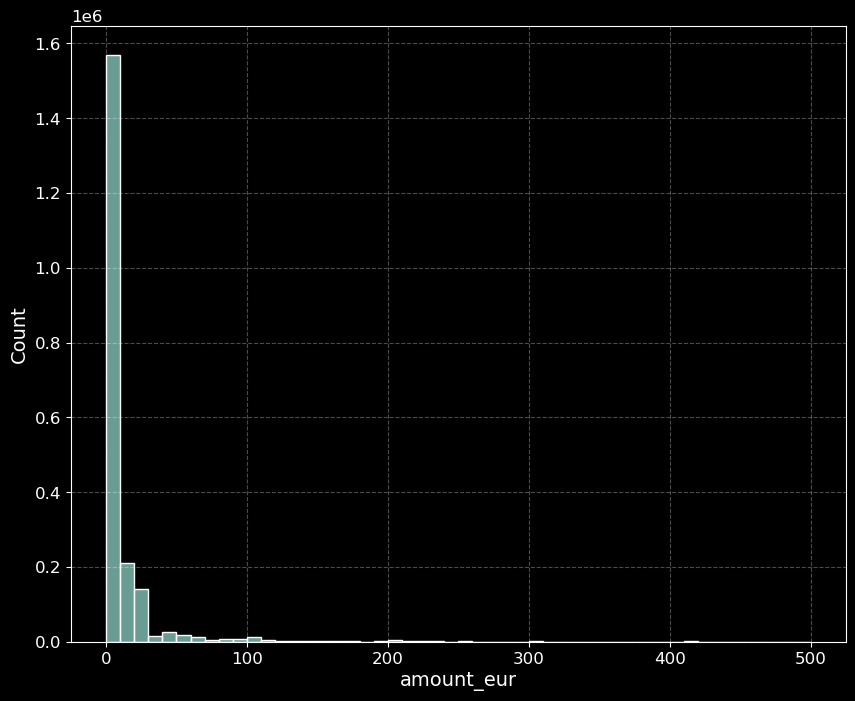

In [42]:
sns.histplot(df[df.amount_eur < 500]['amount_eur'], bins=50)

Analytical Observation:
There is an extreme disparity between the mean and the median (the mean is more than 7 times higher than the median). This indicates a strong right-skewed distribution: 50% of all transactions are micro-donations below 2.32 EUR. The mean is pulled upward by less frequent but significantly larger transfers within the segment.

Hypotheses and Behavioral Patterns:

Mass Social Solidarity:
The vast number of micro-transactions demonstrates that people from all income levels are participating. Even small contributions ("every cent counts") are being sent to protect the country, showing immense social cohesion and respect for the defense forces.

Diversified Recurring Subscriptions:
A median of ~2 EUR is a typical marker of automated monthly subscriptions. Donors likely set up small, recurring payments to multiple different funds simultaneously (e.g., 2 EUR each for drones, medical supplies, and logistics) to support various needs systematically.

FinTech Service Integrations:
Extremely low transaction values (often in cents or single digits) strongly suggest automated micro-donations via service features, such as:

Round-up features: Automatic rounding of bank card payments where the change is donated.

Cashback redirects: Direct transfers of bank cashback to defense funds.

App-based micro-donations: Small percentages added to purchases in delivery or ride-hailing apps (e.g., Bolt).

<Axes: xlabel='amount_eur', ylabel='Count'>

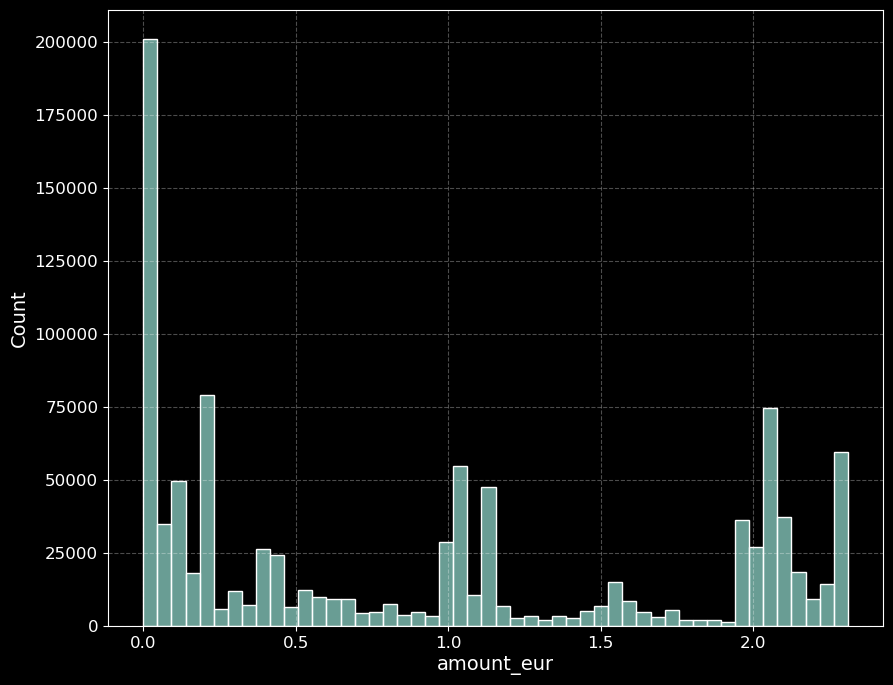

In [43]:
# closer look at micro donates
sns.histplot(df[df.amount_eur < df.amount_eur.median()]['amount_eur'], bins=50)

In [44]:
df[df.amount_eur < 2.32]['amount_eur'].value_counts().head(10)

amount_eur
0.02    113929
0.00     36335
2.30     35859
1.15     33463
0.21     33074
2.06     30383
0.10     26623
0.04     26014
0.20     20203
1.03     19791
Name: count, dtype: int64

I think I was rigth. Micro donations (0.02 EUR) are dominating! I think it's a result of App-based micro-donations, I don't belive people will open their account to pay 0.02 EUR.

In [45]:
df.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source
0,9662778,2026-04-06,come_back_alive,general,87.55,50.31,UAH,UKR ***1983 (4405 UAH),Card payment
1,9662779,2026-04-06,come_back_alive,general,4.97,50.31,UAH,UKR ***7346 (250 UAH),Card payment
2,9662780,2026-04-06,come_back_alive,general,29.81,50.31,UAH,UKR ***7031 (1500 UAH),Card payment
3,9662781,2026-04-06,come_back_alive,general,4.97,50.31,UAH,ISR ***4367 (250 UAH),Card payment
4,9662782,2026-04-06,come_back_alive,general,14.91,50.31,UAH,UKR ***0517 (750 UAH),Card payment


In [46]:
#monthly donations
df['month'] = df.date.dt.strftime('%m - %Y')

In [47]:
monthly = df.groupby('month', as_index = False)\
                        .agg(donations = ('amount_eur', 'sum'),
                             mean = ('amount_eur', 'mean'),
                             median = ('amount_eur', 'median')
                              )
monthly.head()

,month,donations,mean,median
0,01 - 2025,"2,489,716.34",16.68,2.30
1,01 - 2026,"1,782,040.06",17.51,2.47
2,02 - 2025,"3,126,205.35",14.63,2.30
3,02 - 2026,"1,772,237.64",15.61,2.45
4,03 - 2025,"3,072,023.06",20.91,2.30


In [48]:
# transform data
monthly_melted = monthly.melt(id_vars='month', 
                              value_vars=['mean', 'median'], 
                              var_name='metric', 
                              value_name='amount_eur')

In [49]:
monthly_melted.head()

,month,metric,amount_eur
0,01 - 2025,mean,16.68
1,01 - 2026,mean,17.51
2,02 - 2025,mean,14.63
3,02 - 2026,mean,15.61
4,03 - 2025,mean,20.91


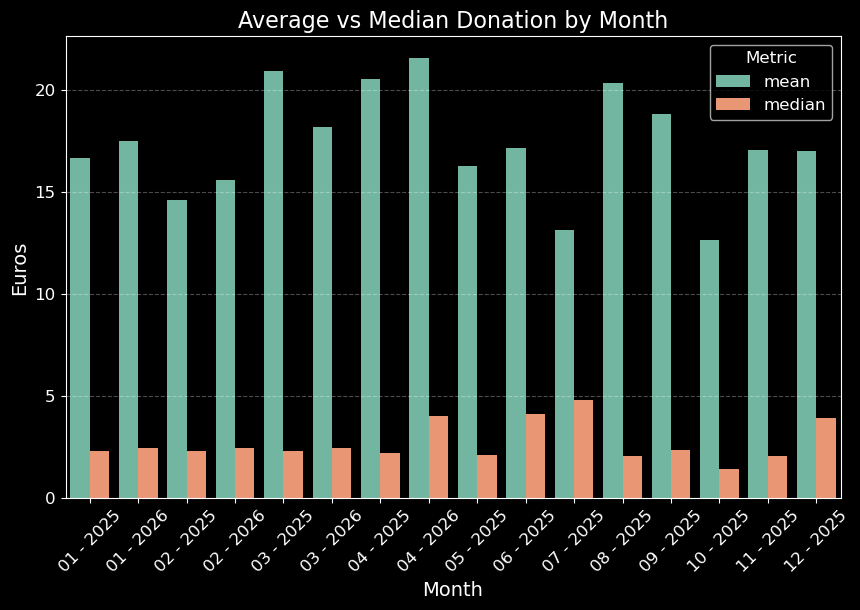

In [50]:
# compare monthly changes in average and median donations
plt.figure(figsize=(10, 6)) 
sns.barplot(data=monthly_melted, x='month', y='amount_eur', hue='metric', palette='Set2') 

plt.xticks(rotation=45)
plt.title('Average vs Median Donation by Month')
plt.ylabel('Euros')
plt.xlabel('Month')
plt.legend(title='Metric')

OK we some similar bars! Let's try statistics!

In [51]:
monthly.head()

,month,donations,mean,median
0,01 - 2025,"2,489,716.34",16.68,2.30
1,01 - 2026,"1,782,040.06",17.51,2.47
2,02 - 2025,"3,126,205.35",14.63,2.30
3,02 - 2026,"1,772,237.64",15.61,2.45
4,03 - 2025,"3,072,023.06",20.91,2.30


In [52]:
monthly[(monthly['month'] == '01 - 2025') | (monthly['month'] == '11 - 2025')].reset_index()

,index,month,donations,mean,median
0,0,01 - 2025,"2,489,716.34",16.68,2.30
1,14,11 - 2025,"1,931,993.79",17.05,2.07


Pretty close, right? 

In [53]:
january  = df.query('month == "01 - 2025"')['amount_eur']
november = df.query('month == "11 - 2025"')['amount_eur']
december = df.query('month == "12 - 2025"')['amount_eur']
june     = df.query('month == "06 - 2025"')['amount_eur']
march    = df.query('month == "03 - 2025"')['amount_eur']

In [54]:
(january == 0).sum()

1669

In [55]:
(november == 0).sum()

1377

In [56]:
# preparing series for normalizing using np.log to make graphs smoother and to avoid deviding to 0
january_ = january.replace(0, 0.001)
november_ = november.replace(0, 0.001)

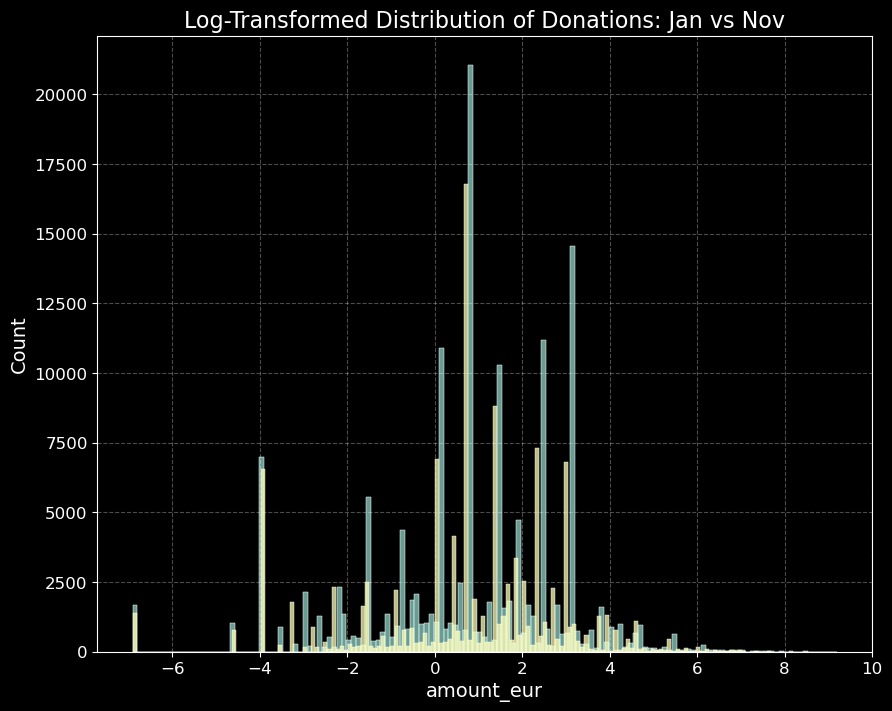

In [57]:
sns.histplot(np.log(january_))
sns.histplot(np.log(november_))
plt.title('Log-Transformed Distribution of Donations: Jan vs Nov')
plt.show()


To confirm whether the average donation amounts are genuinely similar, or if any observed difference is just random noise (a coincidence), I will run an Independent T-test.Our hypotheses for this test:Null Hypothesis: There is no true difference in the average donations between these two months. Any minor variation is purely random.Alternative Hypothesis: There is a statistically significant difference between the months.Let's run the test and let the p-value decide.

In [58]:
ttest_result = pg.ttest(january, november)
display(ttest_result)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.73,"224,687.13",two-sided,0.46,"[-1.36, 0.62]",0.00,0.006,0.12


In [59]:
ttest_result = pg.ttest(np.log(january_), np.log(november_))
display(ttest_result)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.37,"243,147.43",two-sided,0.71,"[-0.01, 0.02]",0.00,0.005,0.07


Incredible! On real-world data, we found absolutely no statistically significant difference between January and November. You rarely see this level of perfect consistency even in synthetic training datasets!

This demonstrates the incredible stability and strength of spirit of the people supporting Ukraine. Their financial support is not just an emotional reaction to news; it is a solid, unbreakable, and systematic commitment.

In [60]:
#let's try ANOVA for similar months
f_stat, p_val = stats.f_oneway(november, december, january, june)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")

F-statistic: 0.3464, p-value: 0.7917


ANOVA analysis revealed no statistically significant differences across four key months ($F = 0.3464, p = 0.7917$). This indicates that the donation ecosystem has evolved from a state of 'emotional response' to a stable 'systemic life-support' model. It is no longer merely charity; it has become a self-imposed monthly tax on justice. Unbelievable!

In [61]:
ttest_result = pg.ttest(january, march)
display(ttest_result)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-8.79,"284,490.59",two-sided,0.00,"[-5.18, -3.29]",0.03,2.374e+14,1.00


In [62]:
ttest_result = pg.ttest(december, march)
display(ttest_result)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-7.47,"297,576.10",two-sided,0.00,"[-4.9, -2.86]",0.03,5.261e+09,1.00


Although March closely approximates the volume of the four-month cluster, statistical testing confirms a significant divergence ($p < 0.05$). This indicates that March stands as a statistical outlier, likely influenced by unique external triggers or specific high-impact campaigns that broke the established baseline of stability.

In [63]:
df.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,month
0,9662778,2026-04-06,come_back_alive,general,87.55,50.31,UAH,UKR ***1983 (4405 UAH),Card payment,04 - 2026
1,9662779,2026-04-06,come_back_alive,general,4.97,50.31,UAH,UKR ***7346 (250 UAH),Card payment,04 - 2026
2,9662780,2026-04-06,come_back_alive,general,29.81,50.31,UAH,UKR ***7031 (1500 UAH),Card payment,04 - 2026
3,9662781,2026-04-06,come_back_alive,general,4.97,50.31,UAH,ISR ***4367 (250 UAH),Card payment,04 - 2026
4,9662782,2026-04-06,come_back_alive,general,14.91,50.31,UAH,UKR ***0517 (750 UAH),Card payment,04 - 2026


Let’s take a look at who transferred money involuntarily — through court.

In [64]:
court_gloss = ['суд', 'судове', 'рішення', 'рішенням', 'вирок', 'ухвала', 'ухвалою', 'постанова', 'постановою', 'застава', 'угода', 'угоди',\
              'прокурор', 'CAП', 'ВАКС', 'штраф', 'стягнення' ]

In [65]:
# expand the list into one string
search_pattern = '|'.join(court_gloss)
df_court = df[df['comment'].str.contains(search_pattern, na=False, case=False)]

In [66]:
df_court.shape

(285, 10)

Only 285 records, I expected more. But it makes it easier to explore!

In [67]:
# top 10 involutarial donations 
df_court.sort_values('amount_eur', ascending = False).reset_index().head(10)

,index,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,month
0,60622,9651081,2026-03-12,come_back_alive,general,"8,245.82",50.93,UAH,"АДВОКАТСЬКЕ ОБ`ЄДНАННЯ ""ТАЛІОН"" -- Благодійна пожертва на виконання угоди пр...",Privat,03 - 2026
1,10469,9652760,2026-03-31,come_back_alive,general,"7,851.95",50.31,UAH,Благодійна пожертва 19Армійському крпусу 9(в/ч5153)зг.вироку суду сп.№991/78...,Privat,03 - 2026
2,10645,9652672,2026-03-31,come_back_alive,general,"7,851.95",50.31,UAH,Благодійна пожертва 19Армійському крпусу 9(в/ч5153)зг.вироку суду сп.№991/78...,Privat,03 - 2026
3,10535,9652826,2026-03-31,come_back_alive,general,"7,851.95",50.31,UAH,Благодійна пожертва 19 Армійському корпусу 9( в/ч 5153)зг.вироку суду від16....,Privat,03 - 2026
4,270028,9377393,2026-01-14,come_back_alive,general,"5,961.62",50.32,UAH,"Братченко Вiкторiя -- Благодiйна допомога на потреби ЗСУ, згiдно Вироку Вищо...",Oschad,01 - 2026
5,270006,9377370,2026-01-14,come_back_alive,general,"5,961.62",50.32,UAH,"Опанасенко Ірина -- «Благ доп на потр ЗСУ, зг Вироку Вищ ант суду року, по с...",Oschad,01 - 2026
6,269863,9377493,2026-01-14,come_back_alive,general,"5,961.62",50.32,UAH,"Опанасенко Євгеній -- Благодійна допомога на потреби ЗСУ, згідно Вироку Вищо...",Oschad,01 - 2026
7,269699,9377593,2026-01-14,come_back_alive,general,"5,961.62",50.32,UAH,"Рожкова Тетяна -- Благодiйна допомога на потреби ЗСУ, згiдно Вироку Вищого а...",Oschad,01 - 2026
8,263239,9387301,2026-01-16,come_back_alive,general,"5,947.96",50.44,UAH,"Дикуша Катерина -- Благодійна допомога на потреби ЗСУ, згідно Вироку Вищого ...",Oschad,01 - 2026
9,2027602,4603063,2025-01-07,come_back_alive,general,"3,299.22",43.91,UAH,ВIХОЛА ТОВ -- Благодiйна Допомога ДОДАТКОВОЇ УГОДИ №9 ВIД ДО,Oschad,01 - 2025


Pretty big numbers, let's see are there repetative court donations

In [68]:
df_court.groupby('comment', as_index = False)\
                    .agg(transactions_count = ('amount_eur','count'), total = ('amount_eur', 'sum'))\
                    .sort_values('transactions_count', ascending = False)\
                    .reset_index(drop = True)\
                    .head(10)

,comment,transactions_count,total
0,Благодійна допомога від Осудар Любов,19,91.66
1,Благодійна допомога від Судаков Володимир,18,176.66
2,Судаков Павло -- Благодійна допомога українцям,16,0.37
3,Табачин Тетяна -- На будь-що на наш розсуд,15,31.58
4,Благодійна допомога від Суденко Ірина,14,29.31
5,Ваксман Сергій -- Збір Повернись живим на навчання операторів БпЛА,12,281.11
6,Благодійна допомога від Ваксман Сергій,11,267.26
7,"Благодійна допомога військовослужбовцям від Судаков Володимир, 5167********9600",9,184.90
8,Благодійна допомога від Сударікова Ольга,8,1.63
9,Благодійна допомога від Ваксман Інна,6,58.05


Not much from leaders, let's check Whales

In [69]:
df_court.groupby('comment', as_index = False)\
                    .agg(transactions_count = ('amount_eur','count'), total = ('amount_eur', 'sum'))\
                    .sort_values('total', ascending = False)\
                    .reset_index(drop = True)\
                    .head(15)

,comment,transactions_count,total
0,"АДВОКАТСЬКЕ ОБ`ЄДНАННЯ ""ТАЛІОН"" -- Благодійна пожертва на виконання угоди пр...",1,"8,245.82"
1,Благодійна пожертва 19 Армійському корпусу 9( в/ч 5153)зг.вироку суду від16....,1,"7,851.95"
2,Благодійна пожертва 19Армійському крпусу 9(в/ч5153)зг.вироку суду сп.№991/78...,1,"7,851.95"
3,Благодійна пожертва 19Армійському крпусу 9(в/ч5153)зг.вироку суду сп.№991/78...,1,"7,851.95"
4,"Братченко Вiкторiя -- Благодiйна допомога на потреби ЗСУ, згiдно Вироку Вищо...",1,"5,961.62"
5,"Опанасенко Євгеній -- Благодійна допомога на потреби ЗСУ, згідно Вироку Вищо...",1,"5,961.62"
6,"Опанасенко Ірина -- «Благ доп на потр ЗСУ, зг Вироку Вищ ант суду року, по с...",1,"5,961.62"
7,"Рожкова Тетяна -- Благодiйна допомога на потреби ЗСУ, згiдно Вироку Вищого а...",1,"5,961.62"
8,"Дикуша Катерина -- Благодійна допомога на потреби ЗСУ, згідно Вироку Вищого ...",1,"5,947.96"
9,Стасюк Олексiй -- Благодійна пожертва на виконання угоди про визнання винува...,2,"5,883.21"


Most of Whales did only one transaction. Finally let's see court money overall and share of all the rest

In [70]:
#key metrics
total   = round(df_court.amount_eur.sum(), 2)
average = round(df_court.amount_eur.mean(), 2)
median  = round(df_court.amount_eur.median(), 3)
share   = round(df_court.amount_eur.sum()/df.amount_eur.sum()*100, 2)

In [71]:
print(f'In total, involuntary donations amounted to {total} €, the average donation was {average} €, the median donation was {median}€,\
                                and the overall share of all donations was {share}%.')

In total, involuntary donations amounted to 105621.19 €, the average donation was 370.6 €, the median donation was 6.09€,                                and the overall share of all donations was 0.31%.


As we can see, the share of involuntary donations is very low (0.31%), which is even below the statistical margin of error, so I can conclude that the overwhelming majority of donors contribute voluntarily, following their own goodwill.

In [72]:
df.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,month
0,9662778,2026-04-06,come_back_alive,general,87.55,50.31,UAH,UKR ***1983 (4405 UAH),Card payment,04 - 2026
1,9662779,2026-04-06,come_back_alive,general,4.97,50.31,UAH,UKR ***7346 (250 UAH),Card payment,04 - 2026
2,9662780,2026-04-06,come_back_alive,general,29.81,50.31,UAH,UKR ***7031 (1500 UAH),Card payment,04 - 2026
3,9662781,2026-04-06,come_back_alive,general,4.97,50.31,UAH,ISR ***4367 (250 UAH),Card payment,04 - 2026
4,9662782,2026-04-06,come_back_alive,general,14.91,50.31,UAH,UKR ***0517 (750 UAH),Card payment,04 - 2026


Let's compare Ukrainian donations with foreign donations!

In [73]:
df.original_currency.nunique()

10

In [74]:
df.original_currency.unique()

array(['UAH', 'USD', 'EUR', 'PLN', 'GBP', 'CHF', 'SEK', 'CZK', 'CAD',
       'NOK'], dtype=object)

<Axes: ylabel='amount_eur'>

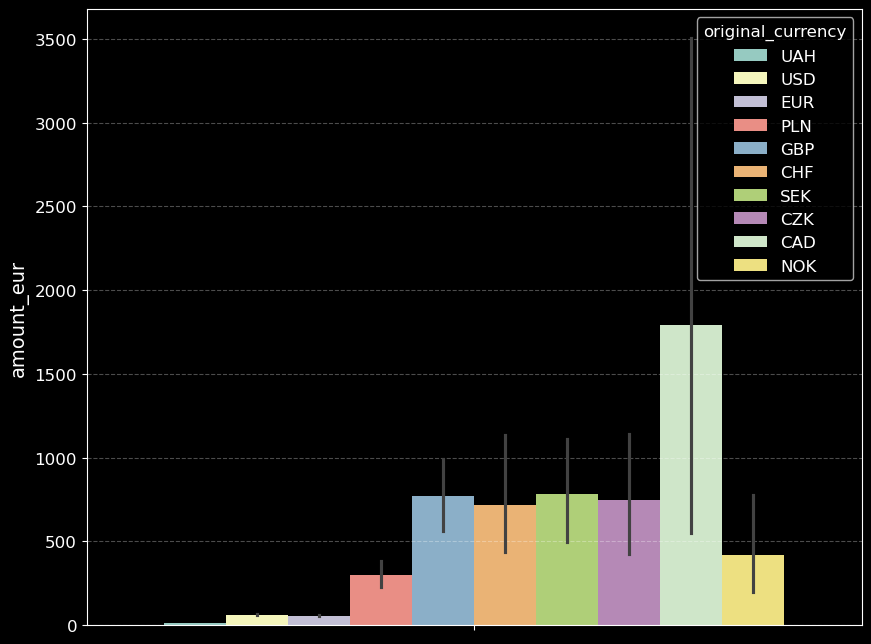

In [75]:
sns.barplot(data = df, y = 'amount_eur', hue = 'original_currency')

Interesting picture, let's explore the numbers!

In [76]:
# pivot the table to get daily amounts for each currency
currency = df.pivot_table(values = 'amount_eur', index = 'month', columns = 'original_currency', aggfunc = 'sum')
currency.head()

original_currency,CAD,CHF,CZK,EUR,GBP,NOK,PLN,SEK,UAH,USD
month,,,,,,,,,,
01 - 2025,NaN,741.35,"10,563.14","197,331.48","2,413.76","1,123.71","3,125.52","1,715.85","2,107,900.06","164,801.47"
01 - 2026,150.23,871.48,"7,423.38","249,329.86","38,801.19",257.56,"3,859.79",NaN,"1,314,532.40","166,814.17"
02 - 2025,659.26,818.73,"5,446.57","298,577.02","10,986.81",771.98,"11,267.14",76.64,"2,529,438.79","268,162.41"
02 - 2026,299.77,874.92,556.58,"220,240.08","2,017.40","1,232.13","10,241.71",NaN,"1,323,724.82","213,050.23"
03 - 2025,"7,033.08",583.04,"7,079.36","408,198.00","7,244.93","1,395.86","7,902.28",898.81,"2,129,881.37","501,806.33"


In [77]:
currency.index = pd.to_datetime(currency.index, format='%m - %Y')
currency = currency.sort_index()

In [78]:
currency.head()

original_currency,CAD,CHF,CZK,EUR,GBP,NOK,PLN,SEK,UAH,USD
month,,,,,,,,,,
2025-01-01,NaN,741.35,"10,563.14","197,331.48","2,413.76","1,123.71","3,125.52","1,715.85","2,107,900.06","164,801.47"
2025-02-01,659.26,818.73,"5,446.57","298,577.02","10,986.81",771.98,"11,267.14",76.64,"2,529,438.79","268,162.41"
2025-03-01,"7,033.08",583.04,"7,079.36","408,198.00","7,244.93","1,395.86","7,902.28",898.81,"2,129,881.37","501,806.33"
2025-04-01,NaN,"1,744.17",740.52,"207,177.89","14,767.00",984.52,"5,027.04",899.37,"1,697,609.59","156,794.27"
2025-05-01,NaN,910.06,"1,245.34","183,387.59","3,381.78","1,250.15","6,391.15",481.31,"1,679,455.14","142,405.77"


In [79]:
currency.sum()

original_currency
CAD       21,532.13
CHF       20,148.64
CZK       56,533.61
EUR    3,512,697.73
GBP      163,481.51
NOK       21,302.13
PLN      124,389.00
SEK       13,282.85
UAH   27,455,677.77
USD    2,851,773.67
dtype: float64

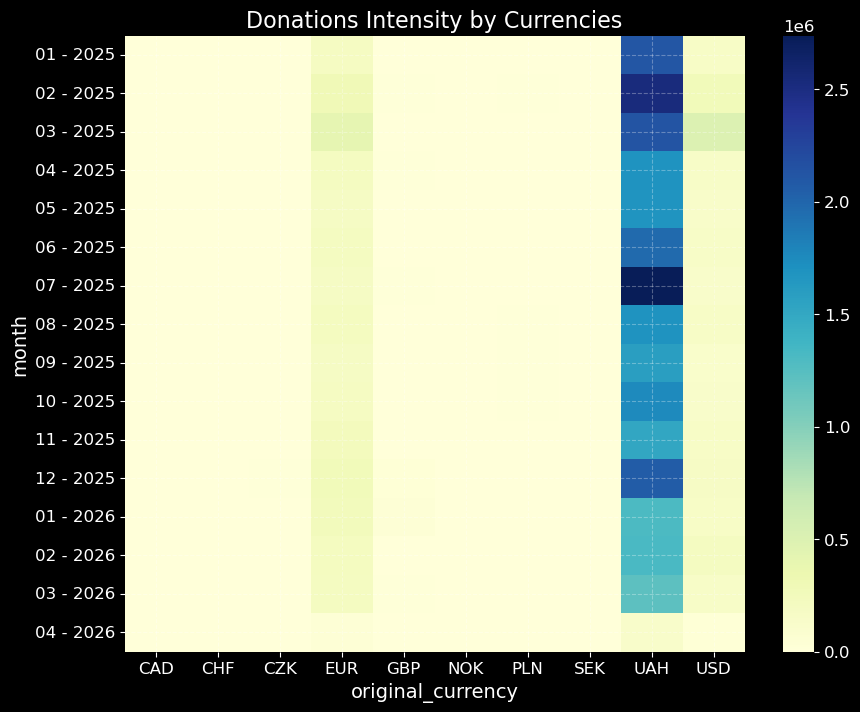

In [80]:
y_axis_labels = [label.strftime('%m - %Y') for label in currency.index]
sns.heatmap(currency.fillna(0), annot=False, cmap="YlGnBu", yticklabels=y_axis_labels)
plt.title("Donations Intensity by Currencies")
plt.show()

Not much of activity from foreign donors, we see little information on this graph

Text(0.5, 1.0, 'Currency Correlations')

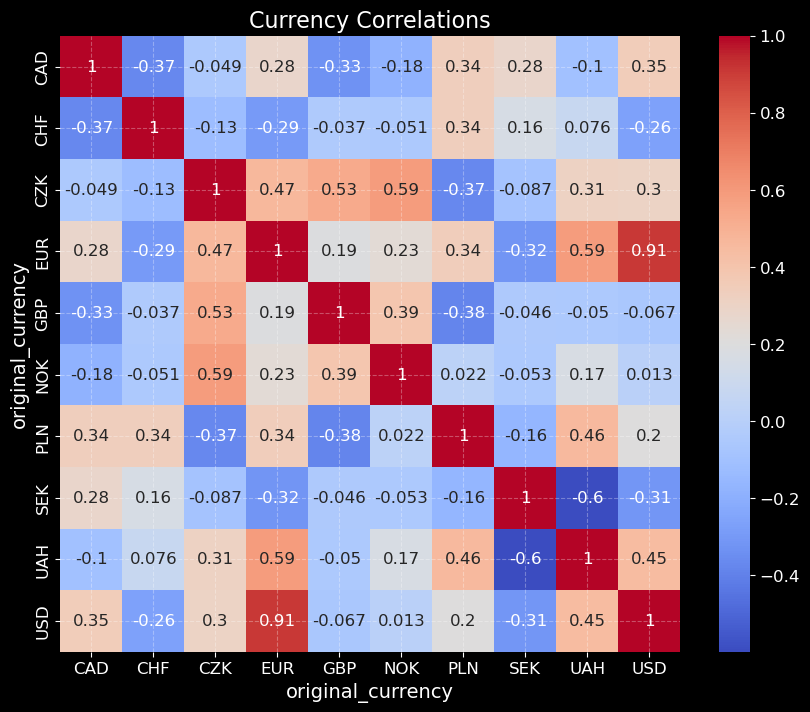

In [81]:
corr = currency.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Currency Correlations")

Look at this heatmap. The numbers don't lie, and they tell a pretty wild story:

USD & EUR: Pure Lockstep (0.91). This isn't just a high correlation — it's basically the same line. The Western donor pool reacts to news and big events as a single entity. If we see a spike in Dollars, the Euro follows almost instantly. They are triggered by the same headlines, same emotions, and same timing.

UAH vs. The World. The local currency (UAH) shows a much lower correlation with the big players (around 0.45-0.5).

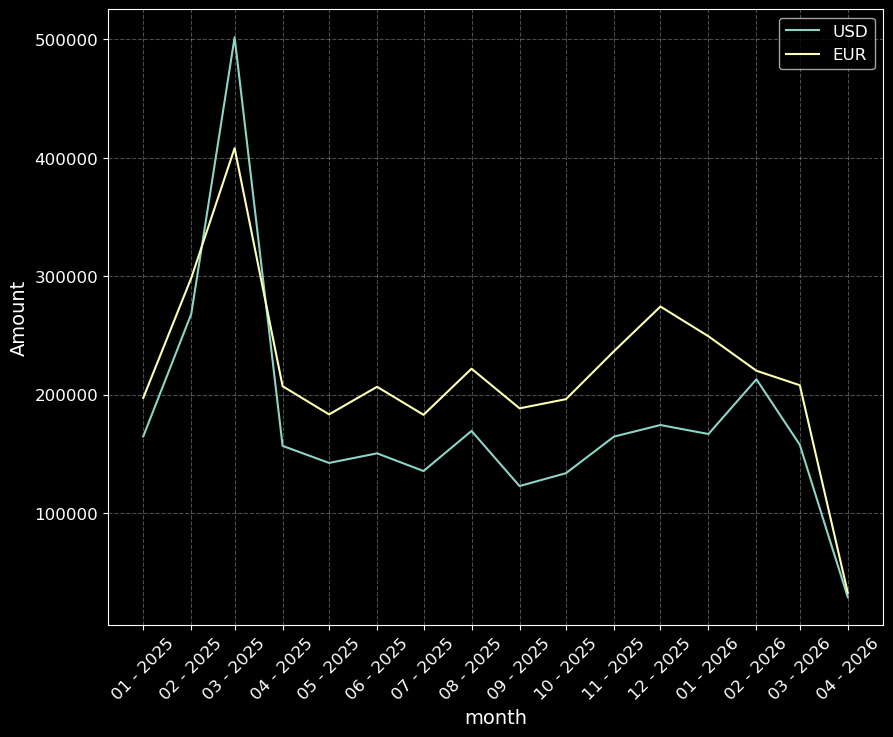

In [82]:
sns.lineplot(x = currency.index, y = currency.USD, label = 'USD')
sns.lineplot(x = currency.index, y = currency.EUR, label = 'EUR')
ax = plt.gca() 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m - %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.ylabel('Amount')
plt.xticks(rotation = 45)
plt.legend()

This is wild. The lines are basically identical.
The 0.91 correlation is clearly visible here—Western donors react to news in total lockstep. It’s the same audience, just different currencies. One global event triggers both at the exact same moment.

Next, we will clean the data by removing noise and seasonality, and then conduct a residual analysis.

In [83]:
usd = df[df['original_currency'] == 'USD'].groupby('date')['amount_eur'].sum()
eur = df[df['original_currency'] == 'EUR'].groupby('date')['amount_eur'].sum()
combined = pd.DataFrame({'eur': eur, 'usd': usd})

In [84]:
# Decomposition (Period=7 for weekly seasonality)
# Using additive model as donation amounts are on similar scales
decomp_eur = seasonal_decompose(combined['eur'], model='additive', period=7)
decomp_usd = seasonal_decompose(combined['usd'], model='additive', period=7)

In [85]:
# Extract residuals
resid_eur = decomp_eur.resid.dropna()
resid_usd = decomp_usd.resid.dropna()
# Calculate correlation on residuals
res_corr = resid_eur.corr(resid_usd)
res_corr

0.46069026771020766

The correlation of the residuals turned out to be lower (0.46), but still quite high, considering that we are analyzing a one-year period.
Let's build a plot!

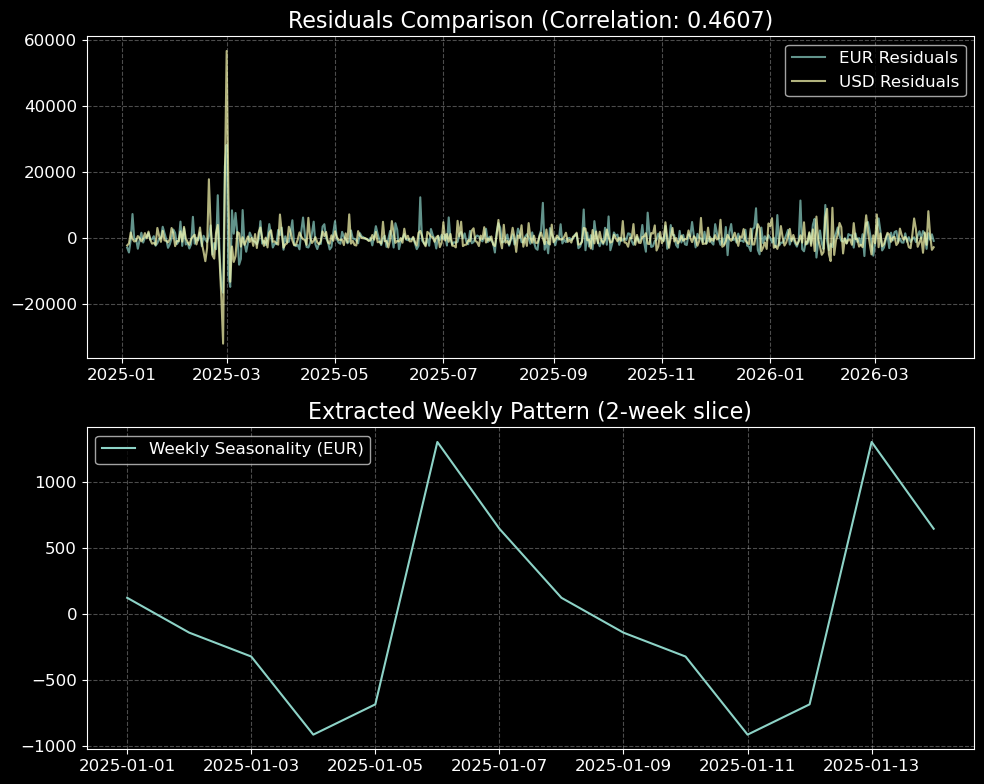

In [86]:
fig, ax = plt.subplots(2, 1)

# Residuals correlation
ax[0].plot(resid_eur, label='EUR Residuals', alpha=0.7)
ax[0].plot(resid_usd, label='USD Residuals', alpha=0.7)
ax[0].set_title(f'Residuals Comparison (Correlation: {res_corr:.4f})')
ax[0].legend()

# Plot seasonal components for visibility
ax[1].plot(decomp_eur.seasonal[:14], label='Weekly Seasonality (EUR)')
ax[1].set_title('Extracted Weekly Pattern (2-week slice)')
ax[1].legend()

plt.tight_layout()
plt.show()

Even after removing weekly seasonality and background noise, the residual trends remain strikingly similar. While the correlation adjusted to 0.46, the synchronized event-driven behavior between EU and US donors is still remarkable. I see significant differences only on march, let's cut it out and check again.

In [87]:
# Cutting off March
eur_f = resid_eur[resid_eur.index > '2025-03-31']
usd_f =resid_usd[resid_eur.index > '2025-03-31']
res_corr = eur_f.corr(usd_f)
res_corr

0.043984407297839825

Oops, I got excited about the insight too early!  After analyzing the residuals post-March, I found a very low correlation of just 0.04. This effectively disproves my hypothesis that Western grassroots donors behave similarly. It’s now clear that the high overall correlation was driven almost entirely by that sharp spike in March.  Let’s now look at the overall share of donations made in foreign currencies relative to all donations.

In [88]:
top_curr = df.groupby('original_currency', as_index = False)\
            .agg(total = ('amount_eur', 'sum'))\
            .sort_values('total', ascending = False)\
            .reset_index(drop = True)
top_curr

,original_currency,total
0,UAH,"27,455,677.77"
1,EUR,"3,512,697.73"
2,USD,"2,851,773.67"
3,GBP,"163,481.51"
4,PLN,"124,389.00"
5,CZK,"56,533.61"
6,CAD,"21,532.13"
7,NOK,"21,302.13"
8,CHF,"20,148.64"
9,SEK,"13,282.85"


In [89]:
#foreign donations
foreign = top_curr.iloc[1:].total.sum()
foreign

6785141.27

In [90]:
#Ukrainian donations
ukrainian = top_curr.iloc[0].total
ukrainian 

27455677.77

In [91]:
foreign_share = round(foreign/ukrainian*100, 2)

In [92]:
print(f'Since 2025 foreign grassroots help to Ukraine share is {foreign_share} %. Which I find really amazing!')

Since 2025 foreign grassroots help to Ukraine share is 24.71 %. Which I find really amazing!


Let's explore dynamics

In [93]:
df.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,month
0,9662778,2026-04-06,come_back_alive,general,87.55,50.31,UAH,UKR ***1983 (4405 UAH),Card payment,04 - 2026
1,9662779,2026-04-06,come_back_alive,general,4.97,50.31,UAH,UKR ***7346 (250 UAH),Card payment,04 - 2026
2,9662780,2026-04-06,come_back_alive,general,29.81,50.31,UAH,UKR ***7031 (1500 UAH),Card payment,04 - 2026
3,9662781,2026-04-06,come_back_alive,general,4.97,50.31,UAH,ISR ***4367 (250 UAH),Card payment,04 - 2026
4,9662782,2026-04-06,come_back_alive,general,14.91,50.31,UAH,UKR ***0517 (750 UAH),Card payment,04 - 2026


In [94]:
df['month'] = df['month'].dt.to_timestamp()

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
all_curr     = df.groupby('month', as_index = False).amount_eur.sum()
foreign_curr = df.query('original_currency != "UAH"')\
                 .groupby('month', as_index = False).amount_eur.sum()

In [ ]:
sns.lineplot(data = all_curr, x = 'month', y = 'amount_eur', label = 'All')
sns.lineplot(data = foreign_curr, x = 'month', y = 'amount_eur', label = 'Foreign')
plt.title('Comparison share of foreign donations in dynamics')

In [ ]:
# Grouping into 'Domestic (UAH)' and 'Foreign'
df['currency_category'] = df['original_currency'].apply(
    lambda x: 'Domestic (UAH)' if x == 'UAH' else 'Foreign'
)

monthly_data = df.groupby([pd.Grouper(key='date', freq='ME'), 'currency_category'])['amount_eur'].sum().unstack().fillna(0)
monthly_share = weekly_data.div(weekly_data.sum(axis=1), axis=0) * 100

In [ ]:
# Plot the 100% stacked bar chart
fig, ax = plt.subplots(figsize=(14, 7))

monthly_share.plot(kind='bar', stacked=True, ax=ax, width=0.8, alpha=0.9, color=['#1f77b4', '#ff7f0e'])

# 5. Chart formatting
ax.set_title('Monthly Donation Share: Domestic vs Foreign Currencies (100% Stacked)')
ax.set_ylabel('Share of Total Donations (%)')
ax.set_xlabel('Month')

# Convert Y axis to percentage format
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

date_labels = [date.strftime('%Y-%m-%d') for date in weekly_share.index]
ax.set_xticklabels(date_labels, rotation=45)
plt.legend(title='Currency Group')
plt.tight_layout()
plt.show()

Foreign donations remain remarkably stable and show little reaction to news events — contrary to my initial hypothesis.
Most likely, these are committed donors who set up recurring monthly contributions, which is common in the West.
The sharp spike in March appears to be a one-time reaction to Trump’s inauguration. Ukrainian donations, by contrast, respond strongly and visibly to current events.